# ✅ Solutions — Module 9 — Correlation & Simple Linear Regression

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf

def diagnostic_plots(model, axes):
    """The four standard diagnostic plots for a fitted statsmodels OLS model (axes: 4 matplotlib axes)."""
    infl = model.get_influence(); fitted, resid = model.fittedvalues, model.resid
    std_resid, leverage = infl.resid_studentized_internal, infl.hat_matrix_diag
    lowess = sm.nonparametric.lowess
    axes[0].scatter(fitted, resid, s=14, alpha=.6); axes[0].plot(*lowess(resid, fitted, frac=.6).T, color=C[3], lw=2); axes[0].axhline(0, color="k", ls="--", lw=1)
    axes[0].set(title="Residuals vs fitted\n(linearity: is the red line flat?)", xlabel="fitted value", ylabel="residual")
    sm.qqplot(std_resid, line="45", ax=axes[1], markersize=3.5); axes[1].set_title("Normal Q–Q\n(normal errors: points on the line?)")
    axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), s=14, alpha=.6); axes[2].plot(*lowess(np.sqrt(np.abs(std_resid)), fitted, frac=.6).T, color=C[3], lw=2)
    axes[2].set(title="Scale–location\n(constant spread: is the red line flat?)", xlabel="fitted value", ylabel="√|standardised residual|")
    axes[3].scatter(leverage, std_resid, s=14 + 600 * infl.cooks_distance[0], alpha=.6); axes[3].axhline(0, color="k", ls="--", lw=1)
    axes[3].set(title="Residuals vs leverage\n(bubble size = Cook's distance)", xlabel="leverage", ylabel="standardised residual")
    for ax in axes: ax.title.set_fontsize(9.5)

### ✍️ Exercise 9.1 — *Pearson vs. Spearman*: Does advertising spend go with revenue? (Marketing)

A marketing team has spend and attributed revenue for 36 campaigns. One of them was a national TV campaign with a huge budget and a disappointing return.

**Tasks**
1. Plot the data. Compute Pearson's $r$ and Spearman's $\rho$ for all campaigns.
2. Recompute both without the TV campaign. Which coefficient is more stable?
3. Compute a bootstrap 95 % CI for Pearson's $r$ among the 35 regular campaigns (resample *pairs*).
4. What do you report — and what do you say about the TV campaign?

In [2]:
g = np.random.default_rng(901)
spend = g.uniform(5, 60, 35); revenue = 40 + 2.2 * spend + g.normal(0, 28, 35)
ads = pd.DataFrame({"campaign": [f"C{i:02d}" for i in range(1, 36)] + ["TV"],
                    "spend_k": np.append(spend, 240).round(1), "revenue_k": np.append(revenue, 150).round(1)})
ads.tail(3)

,campaign,spend_k,revenue_k
33,C34,35.2,162.0
34,C35,46.6,131.8
35,TV,240.0,150.0


all 36 campaigns : Pearson r = 0.41,  Spearman rho = 0.70
without TV       : Pearson r = 0.73,  Spearman rho = 0.69
bootstrap 95 % CI for r (regular campaigns): [0.50, 0.87]


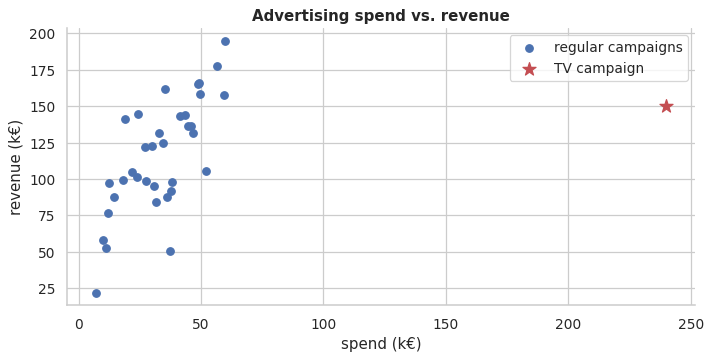

In [3]:
regular = ads[ads.campaign != "TV"]
for name, d in [("all 36 campaigns", ads), ("without TV", regular)]:
    print(f"{name:17s}: Pearson r = {stats.pearsonr(d.spend_k, d.revenue_k)[0]:.2f},  Spearman rho = {stats.spearmanr(d.spend_k, d.revenue_k)[0]:.2f}")
xs, ys = regular.spend_k.values, regular.revenue_k.values
idx = g.integers(0, xs.size, (5000, xs.size)); boot = np.array([np.corrcoef(xs[i], ys[i])[0, 1] for i in idx])
print(f"bootstrap 95 % CI for r (regular campaigns): [{np.quantile(boot, .025):.2f}, {np.quantile(boot, .975):.2f}]")

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(regular.spend_k, regular.revenue_k, color=C[0], label="regular campaigns"); ax.scatter(ads.spend_k.iloc[-1], ads.revenue_k.iloc[-1], color=C[3], s=120, marker="*", label="TV campaign")
ax.set(xlabel="spend (k€)", ylabel="revenue (k€)", title="Advertising spend vs. revenue"); ax.legend(); plt.show()

**Interpretation.** Among the 35 regular campaigns spend and revenue are clearly related ($r\approx0.73$). Adding the single TV campaign makes Pearson's $r$ **collapse**, because that point has enormous leverage; Spearman's $\rho$ barely moves, since on the rank scale the TV campaign is simply "the largest spend with a middling revenue".

**What to report:** the scatterplot, the correlation for the regular campaigns *with its bootstrap interval* (35 points pin $r$ down only to somewhere between 0.5 and 0.87), and the TV campaign **separately** as a qualitatively different case. It is not an "error" to delete — it is information: the spend–revenue relation seen between €5k and €60k does **not** extrapolate to €240k (diminishing returns).

### ✍️ Exercise 9.2 — *Confounding & partial correlation*: Do firefighters cause damage? (Public safety)

A city's data on 300 fires shows: the more firefighters were sent, the higher the damage. A councillor proposes to cut costs *and* damage by sending fewer firefighters.

**Tasks**
1. Compute the raw correlation between firefighters and damage and plot it, colouring points by fire size.
2. Compute the partial correlation controlling for fire size (residual method).
3. Explain the result to the councillor in two sentences.

In [4]:
g = np.random.default_rng(902)
fire_size = g.gamma(2, 2, 300)
firefighters = np.round(3 + 2.5 * fire_size + g.normal(0, 2, 300)).clip(2)
damage = 10 + 12 * fire_size - 1.5 * firefighters + g.normal(0, 8, 300)
fires = pd.DataFrame({"fire_size": fire_size.round(2), "firefighters": firefighters, "damage_k": damage.round(1)})
fires.corr().round(2)

,fire_size,firefighters,damage_k
fire_size,1.00,0.96,0.93
firefighters,0.96,1.00,0.86
damage_k,0.93,0.86,1.00


raw correlation firefighters–damage     : +0.86
partial correlation given fire size      : -0.34


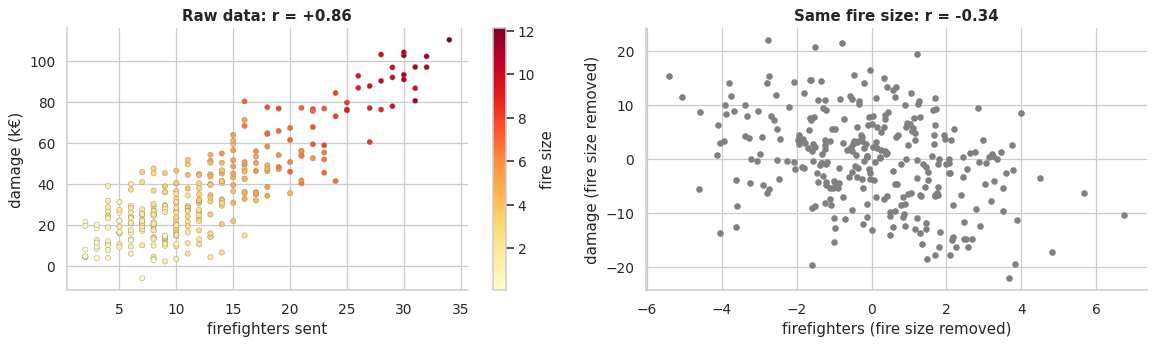

In [5]:
resid = lambda v: v - np.polyval(np.polyfit(fires.fire_size, v, 1), fires.fire_size)
r_raw = fires.firefighters.corr(fires.damage_k); r_part = np.corrcoef(resid(fires.firefighters), resid(fires.damage_k))[0, 1]
print(f"raw correlation firefighters–damage     : {r_raw:+.2f}")
print(f"partial correlation given fire size      : {r_part:+.2f}")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
sc = a1.scatter(fires.firefighters, fires.damage_k, c=fires.fire_size, cmap="YlOrRd", s=18, edgecolor="grey", lw=.3); plt.colorbar(sc, ax=a1, label="fire size")
a1.set(xlabel="firefighters sent", ylabel="damage (k€)", title=f"Raw data: r = {r_raw:+.2f}")
a2.scatter(resid(fires.firefighters), resid(fires.damage_k), s=18, color="grey")
a2.set(xlabel="firefighters (fire size removed)", ylabel="damage (fire size removed)", title=f"Same fire size: r = {r_part:+.2f}"); plt.tight_layout(); plt.show()

**Interpretation.** The raw correlation is strongly positive — but fire size drives **both** variables: big fires get many firefighters *and* cause much damage. Holding fire size constant, the association turns **negative**: among fires of the same size, those with more firefighters suffer *less* damage.

**For the councillor:** "Firefighters don't cause damage — big fires cause both. Comparing fires of equal size, every additional firefighter goes with *less* damage, so cutting crews would increase losses."

**Lesson:** a confounder can not only inflate a correlation, it can flip its sign (Simpson's paradox for continuous data, Module 8).

### ✍️ Exercise 9.3 — *Fitting & interpreting a regression line*: What is a square metre worth? (Real estate)

You have asking prices and living areas of 120 flats in one city district.

**Tasks**
1. Compute slope and intercept **by hand** from the formulas, then fit the model with `smf.ols` and compare.
2. Interpret slope, intercept, $R^2$ and the residual standard error in plain language. Give the 95 % CI of the slope.
3. A 95 m² flat is offered for €420k. Compute the 95 % **prediction interval** for such a flat. Is it overpriced?

In [6]:
g = np.random.default_rng(903)
area = g.uniform(45, 180, 120).round(0)
homes = pd.DataFrame({"area_m2": area, "price_k": (35 + 3.1 * area + g.normal(0, 45, 120)).round(0)})
homes.describe().round(1)

,area_m2,price_k
count,120.0,120.0
mean,116.2,398.0
std,37.3,121.9
min,46.0,119.0
25%,81.0,292.5
50%,120.0,417.0
75%,147.5,493.2
max,177.0,633.0


by hand    : intercept = 42.95, slope = 3.0550   (check: r·sy/sx = 3.0550)
statsmodels: intercept = 42.95, slope = 3.0550
95 % CI slope: [2.84, 3.27] k€/m²;  R² = 0.87;  residual SE = 43.3 k€

95 m² flat: predicted 333 k€, 95 % CI for the mean [324, 342], 95 % prediction interval [247, 419]
asking price 420 k€ is +2.0 residual SDs above the prediction


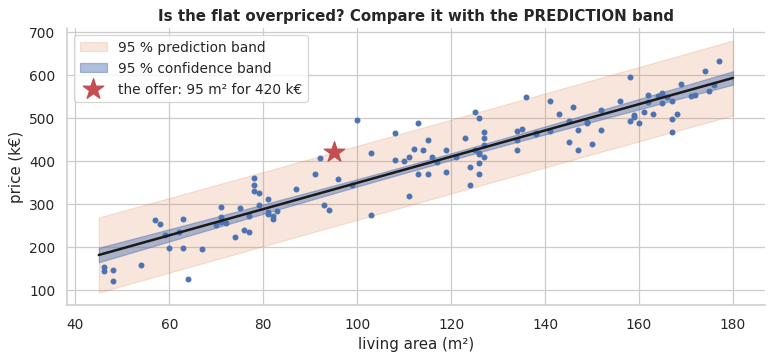

In [7]:
x, y = homes.area_m2, homes.price_k
b1 = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum(); b0 = y.mean() - b1 * x.mean()
m = smf.ols("price_k ~ area_m2", data=homes).fit()
print(f"by hand    : intercept = {b0:.2f}, slope = {b1:.4f}   (check: r·sy/sx = {x.corr(y) * y.std() / x.std():.4f})")
print(f"statsmodels: intercept = {m.params['Intercept']:.2f}, slope = {m.params['area_m2']:.4f}")
print(f"95 % CI slope: [{m.conf_int().loc['area_m2', 0]:.2f}, {m.conf_int().loc['area_m2', 1]:.2f}] k€/m²;  R² = {m.rsquared:.2f};  residual SE = {np.sqrt(m.mse_resid):.1f} k€")
p = m.get_prediction(pd.DataFrame({"area_m2": [95]})).summary_frame(alpha=.05).iloc[0]
print(f"\n95 m² flat: predicted {p['mean']:.0f} k€, 95 % CI for the mean [{p.mean_ci_lower:.0f}, {p.mean_ci_upper:.0f}], 95 % prediction interval [{p.obs_ci_lower:.0f}, {p.obs_ci_upper:.0f}]")
print(f"asking price 420 k€ is {(420 - p['mean']) / np.sqrt(m.mse_resid):+.1f} residual SDs above the prediction")
grid = pd.DataFrame({"area_m2": np.linspace(45, 180, 100)}); pr = m.get_prediction(grid).summary_frame(alpha=.05)
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(grid.area_m2, pr.obs_ci_lower, pr.obs_ci_upper, color=C[1], alpha=.2, label="95 % prediction band"); ax.fill_between(grid.area_m2, pr.mean_ci_lower, pr.mean_ci_upper, color=C[0], alpha=.45, label="95 % confidence band")
ax.plot(grid.area_m2, pr["mean"], "k", lw=2); ax.scatter(homes.area_m2, homes.price_k, s=14, color=C[0]); ax.scatter([95], [420], marker="*", s=300, color=C[3], zorder=4, label="the offer: 95 m² for 420 k€")
ax.set(xlabel="living area (m²)", ylabel="price (k€)", title="Is the flat overpriced? Compare it with the PREDICTION band"); ax.legend(); plt.show()

**Interpretation.**
* **Slope** ≈ 3.06 k€/m²: flats that are 1 m² larger are on average about €3,060 more expensive (95 % CI 2.84–3.27). This is the district's marginal price per square metre.
* **Intercept**: the "price of a 0 m² flat" — a pure extrapolation with no real-world meaning; it just positions the line.
* **$R^2\approx0.87$**: area alone explains most of the price variation. **Residual SE ≈ 43 k€**: prices typically deviate from the line by about ±43 k€ (location, floor, condition …).
* **The 95 m² flat:** predicted ≈ 333 k€; the *confidence* interval for the mean is tight (±9 k€), but that is the wrong interval — we ask about **one flat**, so we need the prediction interval, 247–419 k€. The asking price sits just above its upper edge (+2 residual SDs): expensive for its size, though not impossible — a reason to ask what justifies the premium, not proof of overpricing.

### ✍️ Exercise 9.4 — *Prediction & extrapolation*: How much gas will the city need tomorrow? (Energy utility)

A municipal utility models daily gas demand (MWh) during the heating season as a function of the mean outdoor temperature.

**Tasks**
1. Fit the model and interpret the slope.
2. Tomorrow's forecast is **−2 °C**. Report the 95 % confidence interval for the mean demand and the 95 % prediction interval. Which one matters for capacity planning?
3. A cold snap of **−15 °C** is forecast for next week, and someone also asks about a summer day of **+25 °C**. What does the model predict — and should you trust it?
4. Plot data, line and both bands from −16 to +26 °C and shade the region without data.

In [8]:
g = np.random.default_rng(904)
temp = g.uniform(-4, 16, 90).round(1)
gas = pd.DataFrame({"temp_c": temp, "demand_mwh": (520 - 21 * temp + g.normal(0, 28, 90)).round(0)})
gas.describe().round(1)

,temp_c,demand_mwh
count,90.0,90.0
mean,6.4,388.2
std,5.7,121.4
min,-3.6,185.0
25%,1.8,281.0
50%,5.8,395.5
75%,11.0,482.5
max,15.7,618.0


slope = -21.0 MWh per °C  (95 % CI [-21.9, -20.2]),  residual SE = 22.8 MWh

   temp_c   mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0      -2  564.0          556.0          573.0         518.0         610.0
1     -15  838.0          819.0          856.0         789.0         887.0
2      25   -4.0          -20.0           13.0         -52.0          44.0


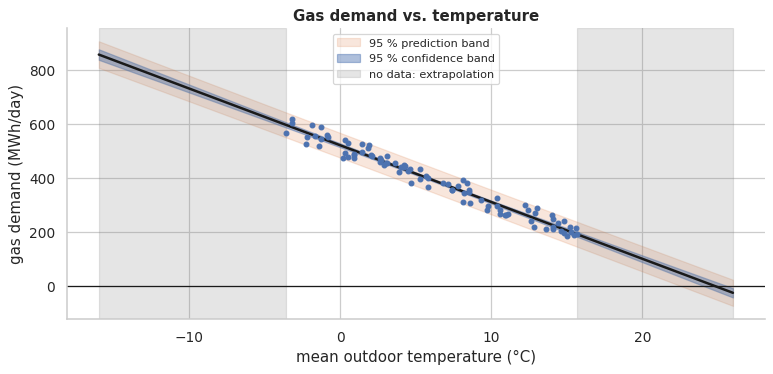

In [9]:
m = smf.ols("demand_mwh ~ temp_c", data=gas).fit()
print(f"slope = {m.params['temp_c']:.1f} MWh per °C  (95 % CI [{m.conf_int().loc['temp_c', 0]:.1f}, {m.conf_int().loc['temp_c', 1]:.1f}]),  residual SE = {np.sqrt(m.mse_resid):.1f} MWh\n")
new = pd.DataFrame({"temp_c": [-2, -15, 25]})
print(pd.concat([new, m.get_prediction(new).summary_frame(alpha=.05)[["mean", "mean_ci_lower", "mean_ci_upper", "obs_ci_lower", "obs_ci_upper"]].round(0)], axis=1))

grid = pd.DataFrame({"temp_c": np.linspace(-16, 26, 120)}); pr = m.get_prediction(grid).summary_frame()
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.fill_between(grid.temp_c, pr.obs_ci_lower, pr.obs_ci_upper, color=C[1], alpha=.2, label="95 % prediction band"); ax.fill_between(grid.temp_c, pr.mean_ci_lower, pr.mean_ci_upper, color=C[0], alpha=.45, label="95 % confidence band")
ax.plot(grid.temp_c, pr["mean"], "k", lw=2); ax.scatter(gas.temp_c, gas.demand_mwh, s=14, color=C[0], zorder=3)
ax.axvspan(-16, gas.temp_c.min(), color="grey", alpha=.2); ax.axvspan(gas.temp_c.max(), 26, color="grey", alpha=.2, label="no data: extrapolation"); ax.axhline(0, color="k", lw=1)
ax.set(xlabel="mean outdoor temperature (°C)", ylabel="gas demand (MWh/day)", title="Gas demand vs. temperature"); ax.legend(fontsize=9); plt.show()

**Interpretation.** Each degree colder adds about **21 MWh** of daily demand. For −2 °C the model predicts ≈ 564 MWh. The *confidence* interval (about ±9 MWh) describes the **average** of all −2 °C days; tomorrow is **one** day, so capacity planning needs the **prediction interval** (about ±46 MWh) — and specifically its **upper end** (≈ 610 MWh), because running short is far more costly than holding reserve.

**Extrapolation:** −15 °C lies 11 °C below the coldest observed day. The model returns a number and a harmless-looking interval, but nothing in the data tells us the relation stays linear there (heating systems saturate, people change behaviour, pipes freeze). At +25 °C the line predicts roughly zero or even *negative* demand — obvious nonsense: in reality demand flattens at a base load once heating is switched off.

**Lesson:** a regression is a description of the data range it was fitted on. Report intervals honestly *and* say where the model has no support.

### ✍️ Exercise 9.5 — *Diagnostics & transformation*: Stopping distance of a car (Road safety)

Test drives recorded the total stopping distance (reaction + braking) at various speeds.

**Tasks**
1. Fit `distance_m ~ speed_kmh` and draw the four diagnostic plots (`diagnostic_plots(model, axes)` from the setup cell). Which assumptions are violated?
2. Fit two alternatives: (a) a quadratic model `distance_m ~ speed_kmh + I(speed_kmh**2)`; (b) a log–log model. Inspect their diagnostics.
3. Compare the three models' predictions at 30, 100 and 160 km/h. What does the straight line predict at 10 km/h?
4. Physics says: distance = reaction distance ($\propto v$) + braking distance ($\propto v^2$). Which model matches the physics, and how do you interpret the log–log slope?

In [10]:
g = np.random.default_rng(905)
speed = g.uniform(20, 130, 150).round(0); v = speed / 3.6
brake = pd.DataFrame({"speed_kmh": speed, "distance_m": ((v * 1.0 + v ** 2 / (2 * 7.0)) * g.lognormal(0, .12, 150)).round(1)})
brake.describe().round(1)

,speed_kmh,distance_m
count,150.0,150.0
mean,75.3,57.4
std,30.6,35.9
min,22.0,9.7
25%,49.0,26.7
50%,75.5,53.6
75%,100.0,83.2
max,130.0,166.4


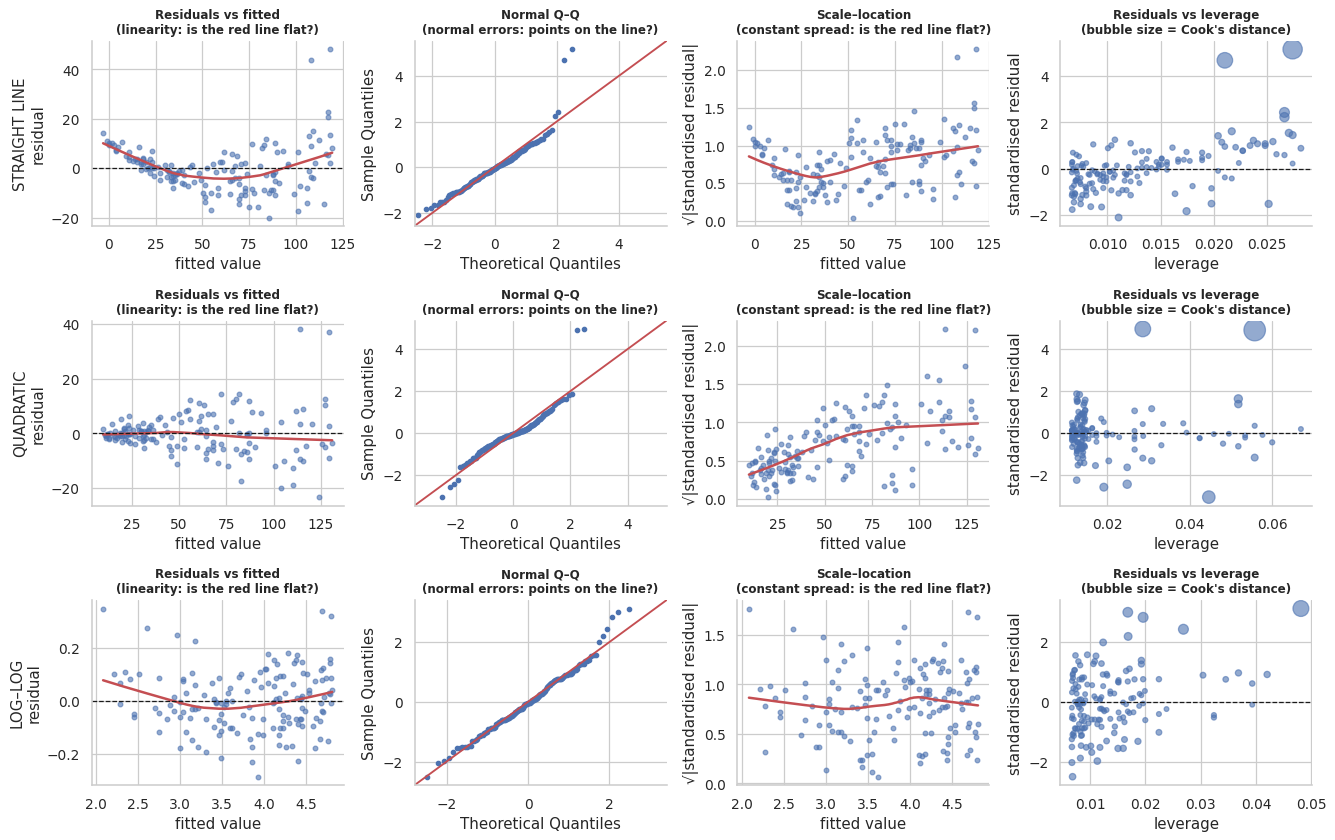

           straight line  quadratic  log–log  physics (no noise)
speed_kmh                                                       
10                 -16.6        5.4      2.4                 3.3
30                   6.1       14.0     13.0                13.3
100                 85.4       82.9     82.0                82.9
160                153.4      190.1    168.3               185.5

log–log slope (elasticity) = 1.53;   R²: line 0.931, quadratic 0.953


In [11]:
m_lin = smf.ols("distance_m ~ speed_kmh", data=brake).fit()
m_quad = smf.ols("distance_m ~ speed_kmh + I(speed_kmh**2)", data=brake).fit()
m_log = smf.ols("np.log(distance_m) ~ np.log(speed_kmh)", data=brake).fit()
fig, axes = plt.subplots(3, 4, figsize=(15, 9.5))
for row, (m, name) in zip(axes, [(m_lin, "straight line"), (m_quad, "quadratic"), (m_log, "log–log")]):
    diagnostic_plots(m, row); row[0].set_ylabel(f"{name.upper()}\nresidual")
plt.tight_layout(); plt.show()

new = pd.DataFrame({"speed_kmh": [10, 30, 100, 160]})
cmp = pd.DataFrame({"straight line": m_lin.predict(new), "quadratic": m_quad.predict(new), "log–log": np.exp(m_log.predict(new))}).round(1); cmp.index = new.speed_kmh
cmp["physics (no noise)"] = ((new.speed_kmh / 3.6) + (new.speed_kmh / 3.6) ** 2 / 14).round(1).values
print(cmp); print(f"\nlog–log slope (elasticity) = {m_log.params.iloc[1]:.2f};   R²: line {m_lin.rsquared:.3f}, quadratic {m_quad.rsquared:.3f}")

**Interpretation.**
* **Straight line:** $R^2$ is high (> 0.9), yet the residual plot shows a clear **U-shape** (the true relation is convex) and a **funnel** (scatter grows with speed). At 10 km/h the line predicts a *negative* stopping distance — a model that is "good on average" can be absurd where it matters.
* **Quadratic:** removes the curvature and reproduces the physics (linear reaction term + quadratic braking term). The funnel remains, because the noise is multiplicative — standard errors are therefore not fully trustworthy (robust SEs or weighting would help; Module 10).
* **Log–log:** removes curvature *and* stabilises the variance. Its slope ≈ 1.5 is an **elasticity**: 1 % more speed → about 1.5 % more stopping distance — between 1 (pure reaction) and 2 (pure braking), as physics demands. It is a convenient approximation rather than the exact law.

Inside the data range the quadratic and log–log models agree closely; **at 160 km/h — outside the data — they begin to differ**, a reminder that extrapolation depends on the functional form you cannot verify.

**Lesson:** never judge a regression by $R^2$ alone; the residual plots tell you whether the *shape* of the model is right.